In [2]:
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd 
import datetime
import scipy
import torch
import tqdm
import xarray as xr

from cartopy.feature import LAND, BORDERS
from dantro.plot.utils import ColorManager
from pyproj import Transformer

# Local imports
import include as base

In [3]:
# Style settings
from matplotlib import rcParams
from cycler import cycler
colors = {
    
    'c_darkblue': '#2F7194',
    'c_red': '#ec7070',
    'c_darkgreen': '#48675A',
    'c_lightblue': '#97c3d0',
    'c_lightgreen': '#AFD8BC',
    'c_lightbrown': '#C6BFA2',
    'c_orange': '#EC9F7E',
    'c_yellow': '#F5DDA9',
    'c_darkgrey': '#3D4244',
    'c_pink': '#F8A6A6',
    'c_purple': '#A07CB0',
    'c_lightgrey': '#AFC1B9',
}
rcParams['axes.prop_cycle'] = cycler(color=list(colors.values()))
fs=9
rcParams.update(**{
    "text.usetex": True,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amssymb} \usepackage{amsmath}",
    "font.size": fs, 
    "axes.titlesize": fs,
    "axes.labelsize": fs,
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
    "legend.fontsize": fs,
    "grid.linewidth": 0.5,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    # "figure.dpi": 300
})
%matplotlib inline

---
# Load datasets
---

In [4]:
start, end = 1990, 2020

In [5]:
# Load the UN net migration data and total population
UN_data = xr.load_dataset("../../../data/Migration/UN_data.nc")
net_migration = UN_data['Net Number of Migrants (thousands)'].transpose('Year', ...).sel({'Year': range(start, end)}) * 1000
total_population = UN_data['Total Population, as of 1 January (thousands)'].transpose('Year', ...).sel({'Year': range(start, end)}) * 1000

# Five-year bilateral flow estimates
five_year_estimates = xr.open_dataset("../../../data/Migration/bilateral_estimates.nc")

# Load the flow estimates from the stock data interpolation
stock_data = xr.load_dataarray("../../../data/Migration/UN_stock_data_ext.nc").transpose("Year", ...).sel({"Year": np.arange(start, end+1, 5)})
stock_diff = stock_data.diff("Year")

# Conversion table for ISO3 codes
iso3_to_name = pd.read_csv("/Users/thomasgaskin/UN_migration_data/Iso_code_lookup.csv").set_index('Alpha-3 code')['Country'].to_dict()

# Country coordinates
country_coords = pd.read_csv("/Users/thomasgaskin/UN_migration_data/Coordinates.csv", index_col=2)
country_coords = country_coords[~country_coords.index.duplicated()]

---
# Rescale and convert to torch.tensor for training
---

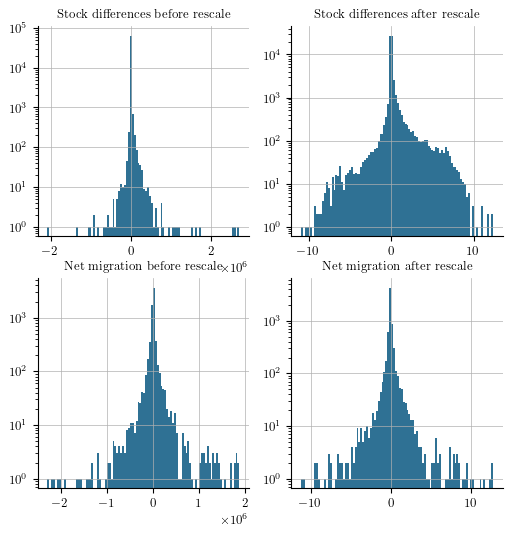

In [6]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(6, 6))
axs[0, 0].set_title("Stock differences before rescale")
axs[0, 0].hist(stock_diff.data.flatten(), bins=100)
axs[0, 0].set_yscale('log')
sigma_stock_diff = np.nanstd(stock_diff.data, axis=-1, keepdims=True)
sigma_stock_diff = np.where(sigma_stock_diff > 0, sigma_stock_diff, 1)
axs[0, 1].set_title("Stock differences after rescale")
axs[0, 1].hist((stock_diff.data / sigma_stock_diff).flatten(), bins=100)
axs[0, 1].set_yscale('log')

axs[1, 0].set_title("Net migration before rescale")
axs[1, 0].hist(net_migration.data.flatten(), bins=100)
axs[1, 0].set_yscale('log')
sigma_net_migr = np.nanstd(net_migration.data, axis=-1, keepdims=True)
sigma_net_migr = torch.from_numpy(np.where(sigma_net_migr > 0, sigma_net_migr, 1)).float()
axs[1, 1].set_title("Net migration after rescale")
axs[1, 1].hist((net_migration.data / sigma_net_migr).flatten(), bins=100)
axs[1, 1].set_yscale('log')
fig.subplots_adjust(wspace=0.2, hspace=0.2)

In [7]:
# Convert the net migration to torch
net_migration_training_data = torch.from_numpy(net_migration.data).float() / sigma_net_migr

N = net_migration_training_data.shape[1]

# Convert the stock data to torch
# sigma_stock = np.nanstd(stock_data.data, axis=-1, keepdims=True)
# sigma_stock = np.where(sigma_stock > 0, sigma_stock, 1)
stock_training_data = torch.from_numpy(stock_data.data).float() #/ sigma_stock
sigma_stock_diff = np.nanstd(stock_diff.data, axis=-1, keepdims=True)
sigma_stock_diff = torch.from_numpy(np.where(sigma_stock_diff > 0, sigma_stock_diff, 1)).float()
stock_training_data_diff = (torch.diff(stock_training_data, dim=0) / sigma_stock_diff).reshape(-1, N**2)

beta = torch.concat([torch.from_numpy(np.repeat([sigma_stock_diff[i]], 5, axis=0)) for i in range(len(sigma_stock_diff))])

# Convert total population to torch and rescale
total_population_training_data = torch.from_numpy(total_population.data).float() 
sigma_total_pop = torch.std(total_population_training_data, axis=-1, keepdim=True)
total_population_training_data /= sigma_total_pop

# Get the mask for the stock data differences
mask = ~torch.isnan(stock_training_data_diff)

---
# Setup and train the neural network
---

In [8]:
sigma_total_pop.shape, sigma_net_migr.shape

(torch.Size([30, 1]), torch.Size([30, 1]))

In [9]:
NN = base.NeuralNet(
    input_size=N,
    output_size=2*N**2,
    num_layers=5,
    nodes_per_layer=dict(default=20),
    activation_funcs=dict(default='silu', layer_specific={1: 'swish', -1: 'abs'}),
    biases=dict(default=None), 
    optimizer='Adam',
    learning_rate=0.002,
)

# Store training loss in array
loss_dict = {
    'stock': [], 
    'net_migration': [],
    'trace': [], 
    'flow': [], 
    'all': []
}

In [10]:
# # Perturbation level during training
# perturbation = 0.0
#     # Perturb the prediction
#     # prediction = prediction * torch.normal(1.0, perturbation, prediction.shape)

In [11]:
transformation_matrix = (beta / sigma_net_migr.reshape(-1, 1, 1)).reshape(-1, 1, N, 1)

In [14]:
transformation_matrix.shape

torch.Size([30, 1, 236, 1])

In [1250]:
def _step(*, which: tuple, idx_range: tuple, idx = None):
    
    # Scaling parameters
    # _alpha = sigma_net_migr[slice(*idx_range)]
    # _beta = sigma_stock_diff[idx]
    _l_dict = {}
    loss = torch.tensor(0.0)
    
    # Make a (transformed) prediction, of shape L, 2, N, N
    prediction = NN(net_migration_training_data[slice(*idx_range)]).reshape(-1, 2, N, N)
    
    # Transform the prediction back
    prediction_transf = prediction * transformation_matrix[slice(*idx_range)]
    
    # Calculate the stock difference on the transformed data
    if 'stock' in which:
        predicted_stock_diff = (prediction[:, 0, :] - prediction[:, 1, :]).sum(dim=0).reshape(N**2)
        stock_err = torch.pow(predicted_stock_diff[mask[idx]] - stock_training_data_diff[idx][mask[idx]], 2).mean()
        loss = loss + stock_err
        _l_dict['stock'] = stock_err.clone().detach()
    
    # Calculate the net migration difference on the transformed flows
    if 'net_migration' in which:
    
        # Calculate the total inflow and outflow
        predicted_outflow = (prediction_transf[:, 0, :] + prediction_transf.transpose(-2, -1)[:, 1, :]).sum(dim=-1)
        predicted_inflow = (prediction_transf.transpose(-2, -1)[:, 0, :] + prediction_transf[:, 1, :]).sum(dim=-1)
        
        # Calculate the predicted net migration
        predicted_net_migration = predicted_inflow - predicted_outflow
        net_migr_err = torch.pow(predicted_net_migration - net_migration_training_data[slice(*idx_range)], 2).mean()
        loss = loss + net_migr_err
        _l_dict['net_migration'] = net_migr_err.clone().detach()
    
    # Penalise the trace
    if 'trace' in which:
        trace_err = torch.diagonal(prediction_transf.sum(dim=1), dim1=-2, dim2=-1).sum()
        loss = loss + trace_err
        _l_dict['trace'] = trace_err.clone().detach()
    
    if 'flow' in which:
        
        # Transform the prediction back and rescale to population variance
        prediction_transf_pop = prediction_transf * sigma_net_migr[slice(*idx_range)].reshape(-1, 1, 1, 1) / sigma_total_pop[slice(*idx_range)].reshape(-1, 1, 1, 1)

        predicted_outflow = (prediction_transf_pop[:, 0, :] + prediction_transf_pop.transpose(-2, -1)[:, 1, :]).sum(dim=-1)
        predicted_inflow = (prediction_transf_pop.transpose(-2, -1)[:, 0, :] + prediction_transf_pop[:, 1, :]).sum(dim=-1)
        
        inflow_err = torch.relu(predicted_inflow - total_population_training_data[slice(*idx_range), :]).sum()
        outflow_err = torch.relu(predicted_outflow - total_population_training_data[slice(*idx_range), :]).sum()
        loss = loss + inflow_err
        loss = loss  + outflow_err
        _l_dict['flow'] = inflow_err.clone().detach() + outflow_err.clone().detach()
        
    # loss = torch.tensor(0.0)
    # _l_dict = {}
    # Calculate all
    # if 'all' in which:
    #     which = ['abs_stock', 'abs_migr', 'trace', 'flow']
    # 
    # # Calculate the errors
    # 
    # 
    # if 'abs_migr' in which:
    #     abs_net_migr_err = torch.pow(predicted_net_migration - net_migration_training_data[slice(*idx_range)], 2).mean()
    #     loss = loss + abs_net_migr_err
    #     _l_dict['abs_migr'] = abs_net_migr_err.clone().detach()

    # # if 'trace' in which:
    # #     loss = loss + torch.nn.functional.mse_loss(
    # #         torch.diagonal(prediction.sum(dim=1), dim1=-2, dim2=-1), torch.zeros((prediction.shape[0], N)))
    # # 
    # # if 'flow' in which:
    # #     inflow_err = torch.relu(predicted_inflow - total_population[slice(*idx_range), :]).sum()
    # #     outflow_err = torch.relu(predicted_outflow - total_population[slice(*idx_range), :]).sum()
    # #     loss = loss + inflow_err
    # #     loss = loss  + outflow_err
    # #     _l_dict['flow'] = inflow_err.clone().detach() + outflow_err.clone().detach()
    # # 
    loss.backward()
    NN.optimizer.step()
    NN.optimizer.zero_grad()
    
    return _l_dict

In [1251]:
sigma_net_migr.shape

torch.Size([30, 1])

In [1266]:
for _ in (pbar:=tqdm.tqdm(range(5000))):
    
    epoch_loss = dict((k, []) for k in loss_dict.keys())
    
    for b in range(len(stock_training_data_diff)):
        
        _l = _step(idx=b, idx_range=(5*b, (b+1)*5), which=('stock', 'net_migration', 'trace', 'flow'))
        for key in _l.keys():
            epoch_loss[key].append(_l[key])

    # _l = _step(idx_range=(-2, None), which=('abs_migr', ))
    # for key in _l.keys():
    #     epoch_loss[key].append(_l[key])
    for key in epoch_loss.keys():
        if epoch_loss[key]:
            loss_dict[key].append(np.mean(epoch_loss[key]))

100%|██████████| 5000/5000 [08:01<00:00, 10.39it/s]


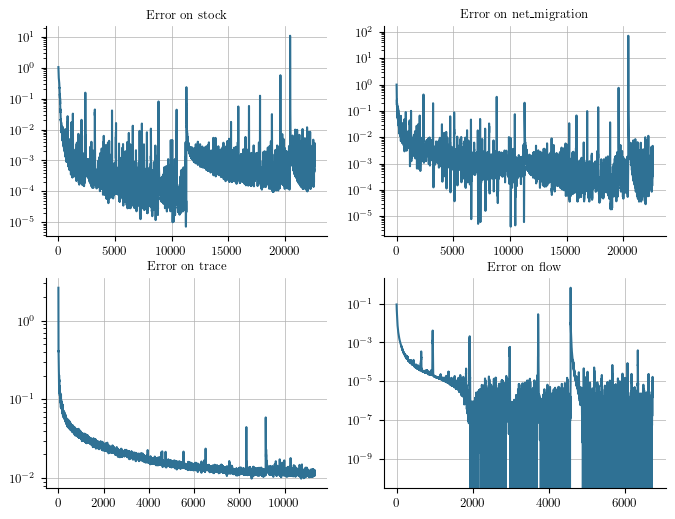

In [1267]:
fig, axs = plt.subplots(ncols=int(len(loss_dict.keys())/2), nrows=int(len(loss_dict.keys())/2), figsize=(8, 6))
for idx, key in enumerate(loss_dict.keys()):
    if loss_dict[key]:
        axs.flatten()[idx].plot(np.arange(len(loss_dict[key])), loss_dict[key], label=key)
        axs.flatten()[idx].set_yscale('log')
        axs.flatten()[idx].set_title(f"Error on {key}")

In [1268]:
predictions = NN(net_migration_training_data).reshape(-1, 2, N, N).detach() * transformation_matrix.reshape(-1, 1, N, 1) * sigma_net_migr.reshape(-1, 1, 1, 1)
# for b in range(len(sigma_stock_diff)):
#     for i in range(5):
#         predictions[5*b+i] *= sigma_stock_diff[b]
flows = predictions[:, 0, :] + predictions.transpose(-2, -1)[:, 1, :]
predictions = xr.DataArray(
    data=predictions,
    dims=["Year", "Direction", "Citizen ISO", "Partner ISO"],
    coords={"Year": net_migration.coords["Year"].data, "Direction": ["Out", "In"], "Citizen ISO": UN_data.coords["Country ISO"].data, 
            "Partner ISO": UN_data.coords["Country ISO"].data}
)
predicted_net_migration = xr.DataArray(
    data=flows.transpose(-2, -1).sum(dim=2) - flows.sum(dim=2),
    dims=["Year", "Country ISO"],
    coords={"Year": net_migration.coords["Year"].data, "Country ISO": UN_data.coords["Country ISO"].data}
)
flows = xr.DataArray(
    data=flows, 
    dims=["Year", "Origin ISO", "Destination ISO"], 
    coords={"Year": net_migration.coords["Year"].data, "Origin ISO": UN_data.coords["Country ISO"].data, "Destination ISO": UN_data.coords["Country ISO"].data}
)

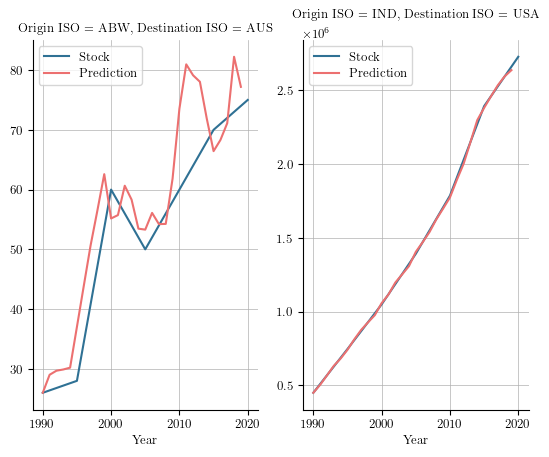

In [1269]:
fig, axs = plt.subplots(ncols=2)
for idx, (org, dest) in enumerate([("ABW", "AUS"), ("IND", "USA")]):
    ax = axs.flatten()[idx]
    stock_data.sel({"Origin ISO": org, "Destination ISO": dest}).plot(ax=ax, label="Stock") 
    
    stock = [stock_data.sel({"Year": start, "Origin ISO": org, "Destination ISO": dest}).data]
    for y in predictions.coords["Year"].data[1:]:
        stock.append(
            stock[-1] + predictions.sel({"Citizen ISO": org, "Partner ISO": dest, "Direction": "Out", "Year": y}, drop=True) - predictions.sel({"Citizen ISO": org, "Partner ISO": dest, "Direction": "In", "Year": y}, drop=True)
        )
    ax.plot(predictions.coords["Year"].data, np.array(stock), label="Prediction")
    ax.legend()

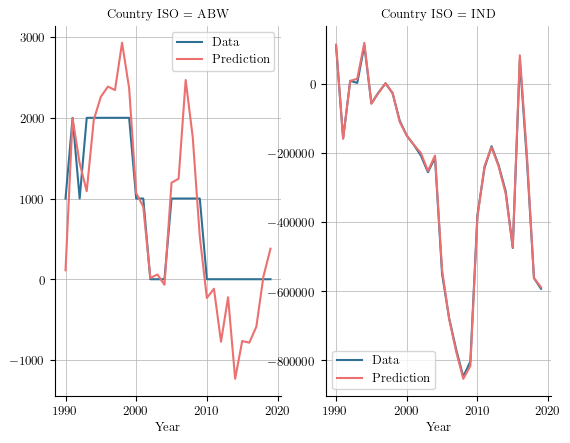

In [1270]:
fig, axs = plt.subplots(ncols=2)
for idx, c in enumerate(["ABW", "IND"]):
    ax =axs[idx]
    net_migration.sel({"Country ISO": c}).plot(ax=ax, label="Data")
    (predicted_net_migration.sel({"Country ISO": c})).plot(ax=ax, label="Prediction")
    ax.legend()

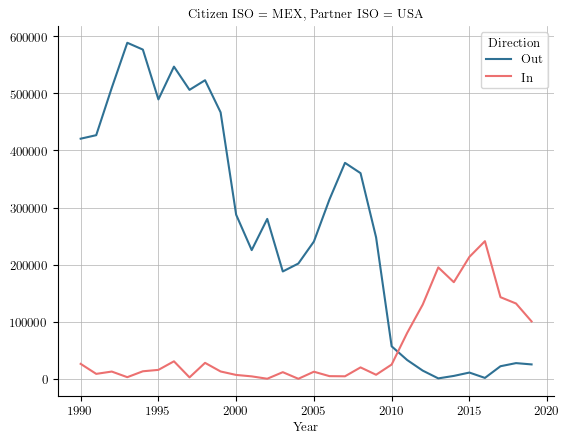

In [1271]:
fig, ax = plt.subplots()
predictions.sel({"Citizen ISO": "MEX", "Partner ISO": "USA"}).plot(ax=ax, hue="Direction")
# (predictions.sel({"Citizen ISO": "IND", "Partner ISO": "GBR", "Direction": "In"}) - predictions.sel({"Citizen ISO": "IND", "Partner ISO": "GBR", "Direction": "Out"})).plot(ax=ax)

In [1272]:
flows.sel({"Origin ISO": "USA", "Destination ISO": "USA"})

<xarray.DataArray (Year: 30)> Size: 120B
array([1.004394  , 0.79964876, 1.062481  , 1.6085927 , 1.5786254 ,
       0.5306312 , 1.0279443 , 0.5857209 , 0.4352261 , 0.31670198,
       4.761756  , 2.7556367 , 4.56244   , 2.9413571 , 2.583591  ,
       2.465896  , 1.9988575 , 1.9854698 , 2.8050652 , 0.9020863 ,
       0.25112468, 0.53535557, 0.41036478, 0.6982719 , 0.6745684 ,
       0.9411957 , 0.8954977 , 0.66943264, 0.1698044 , 0.41876143],
      dtype=float32)
Coordinates:
  * Year             (Year) int64 240B 1990 1991 1992 1993 ... 2017 2018 2019
    Origin ISO       <U3 12B 'USA'
    Destination ISO  <U3 12B 'USA'

In [1273]:
flows.sel({"Origin ISO": "ABW"}).sum("Destination ISO")

<xarray.DataArray (Year: 30)> Size: 120B
array([48138.984, 39125.96 , 41323.957, 51728.65 , 47435.14 , 40714.332,
       47359.535, 40062.375, 37262.938, 34978.85 , 56054.36 , 37713.266,
       57627.438, 38853.18 , 37950.625, 40806.71 , 60324.652, 66892.43 ,
       50728.695, 38147.39 , 32692.5  , 50201.164, 53412.2  , 78877.28 ,
       63971.504, 73712.414, 83900.92 , 59125.945, 54081.812, 47066.5  ],
      dtype=float32)
Coordinates:
  * Year        (Year) int64 240B 1990 1991 1992 1993 ... 2016 2017 2018 2019
    Origin ISO  <U3 12B 'ABW'

In [1274]:
pred_five_year_estimates = []
for y in [1990, 1995, 2000, 2005, 2010, 2015]:
    pred_five_year_estimates.append(
        flows.sel({"Year": range(y, y+5)}).sum("Year")
    )
pred_five_year_estimates = xr.concat(pred_five_year_estimates, dim=pd.Index([1990, 1995, 2000, 2005, 2010, 2015], name="Year0"))

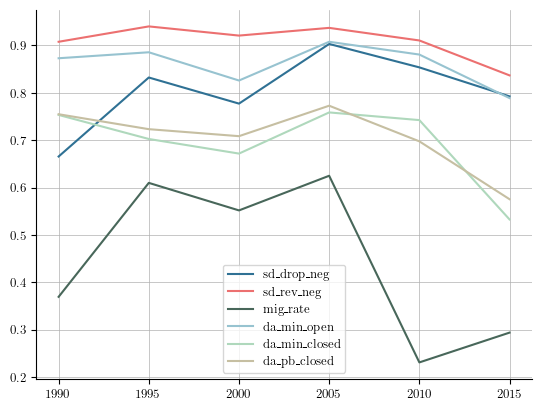

In [1275]:
common_countries  = np.intersect1d(five_year_estimates.coords["Origin ISO"], pred_five_year_estimates.coords["Origin ISO"])
fig, ax = plt.subplots()
for var in list(five_year_estimates.data_vars):
    r_coeffs = []
    for year in five_year_estimates.coords["Year0"]:
        x = pred_five_year_estimates.sel({"Year0": year, "Origin ISO": common_countries, "Destination ISO": common_countries}).data.flatten()
        y = five_year_estimates[var].sel({"Year0": year, "Origin ISO": common_countries, "Destination ISO": common_countries}).data.flatten()
        msk = np.where(~np.isnan(y))
        r_coeffs.append(scipy.stats.pearsonr(x[msk], y[msk]).statistic)
    ax.plot(five_year_estimates.coords["Year0"], r_coeffs, label=var)
ax.legend()

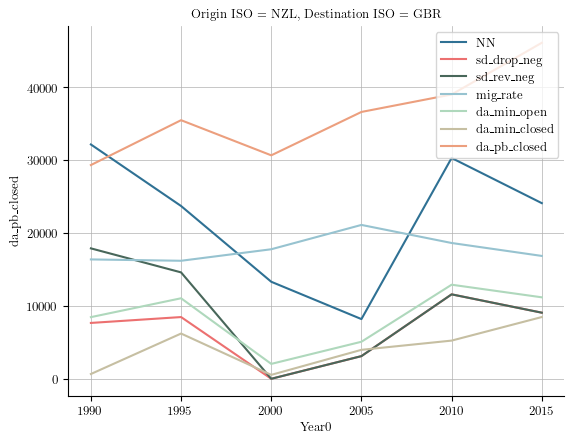

In [261]:
fig, ax = plt.subplots()
org, dest = "NZL", "GBR"
pred_five_year_estimates.sel({"Origin ISO": org, "Destination ISO": dest}).plot(ax=ax, label='NN')
for var in five_year_estimates.data_vars:
    five_year_estimates[var].sel({"Origin ISO": org, "Destination ISO": dest}).plot(ax=ax, label=var)
ax.legend()

In [146]:
extended_flow = xr.open_dataset("/Users/thomasgaskin/bilateral_flows_stats_noiseless.nc")
UN_net_migration = xr.open_dataarray("../../../data/Migration/UN_net_migration.nc")
flow_table = xr.Dataset(dict(
    mean = extended_flow["mean"].sel({"Direction": "Out"}) + extended_flow["mean"].sel({"Direction": "In"}).data.transpose(0, 2, 1),
    std = np.sqrt(
        extended_flow["std"].sel({"Direction": "Out"})**2 + extended_flow["std"].sel({"Direction": "In"}).data.transpose(0, 2, 1)**2
    )
))
predicted_net_migration = xr.Dataset(dict(
    mean = flow_table["mean"].sum("Origin ISO").rename({"Destination ISO": "Country ISO"}) - flow_table["mean"].sum("Destination ISO").rename({"Origin ISO": "Country ISO"}),
    std = np.sqrt((flow_table["std"]**2).sum("Origin ISO").rename({"Destination ISO": "Country ISO"}) + (flow_table["std"]**2).sum("Destination ISO").rename({"Origin ISO": "Country ISO"}))
))

In [294]:
extended_flow.sel({"Origin ISO": "ABW"})["mean"].sum("Destination ISO")

<xarray.DataArray 'mean' (Year: 32, Direction: 2)> Size: 512B
array([[39543.69222541, 41327.84539867],
       [35186.10238679, 36312.28474538],
       [41360.41315909, 41871.03709981],
       [44281.7757303 , 44084.09279878],
       [45441.9520773 , 47070.29178052],
       [35325.10122633, 36036.22229829],
       [44047.51398548, 43867.54570846],
       [36241.32830533, 36891.68142581],
       [35487.85332828, 35725.54873197],
       [35610.7427386 , 36051.19010192],
       [42361.40510771, 44078.46523038],
       [32498.27792297, 33679.60418663],
       [38794.62882867, 39313.40828925],
       [32126.24811375, 31780.07962076],
       [33560.11361249, 33589.1550499 ],
       [35400.32919488, 35621.17087478],
       [46706.11699197, 47041.47433882],
       [47195.93781993, 48588.07656776],
       [48604.62208766, 48070.11371441],
       [37545.31988984, 37604.63019444],
       [35400.5902906 , 35642.54743863],
       [46797.8196236 , 47048.94773683],
       [47606.25509276, 49193.05353964],
       [51438.27881994, 53846.34744651],
       [49242.24933965, 49811.19511988],
       [49807.31880943, 49523.39000735],
       [50218.57214713, 49332.64342852],
       [46417.22499573, 45393.205534  ],
       [46606.75693091, 45752.71227966],
       [41662.01157512, 41238.01794251],
       [34296.42697555, 33871.60073445],
       [23666.0895067 , 23681.04050584]])
Coordinates:
    Origin ISO  <U3 12B 'ABW'
  * Year        (Year) int32 128B 1990 1991 1992 1993 ... 2018 2019 2020 2021
  * Direction   (Direction) object 16B 'Out' 'In'

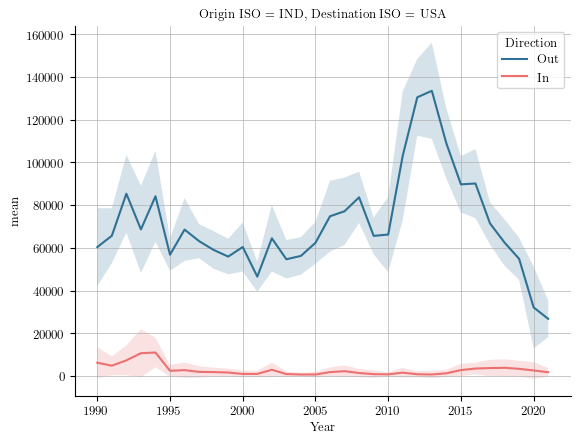

In [148]:
fig, ax = plt.subplots()
org, dest = "IND", "USA"
m = extended_flow.sel({"Origin ISO": org, "Destination ISO": dest})["mean"]
std = extended_flow.sel({"Origin ISO": org, "Destination ISO": dest})["std"]
for dir in ["Out", "In"]:
    ax.fill_between(extended_flow.coords["Year"].data, m.sel({"Direction": dir})-std.sel({"Direction": dir}), m.sel({"Direction": dir})+std.sel({"Direction": dir}), alpha=0.2)
m.plot.line(hue="Direction", ax=ax)

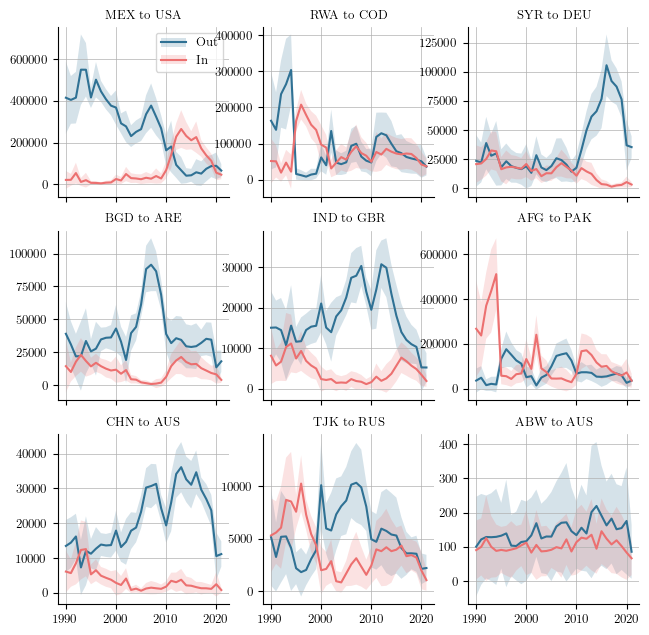

In [149]:
fig, axs = plt.subplots(ncols=3, nrows=3, sharex=True, figsize=(7.5, 7.5))
pairs = [["MEX", "USA"], ["RWA", "COD"], ["SYR", "DEU"], ["BGD", "ARE"], ["IND", "GBR"], ["AFG", "PAK"], ["CHN", "AUS"], ["TJK", "RUS"], ["ABW", "AUS"]]
for idx, pair in enumerate(pairs):
    org, dest = pair
    handles = []
    for dir in ["Out", "In"]:
        m = extended_flow.sel({"Origin ISO": org, "Destination ISO": dest, "Direction": dir})["mean"]
        std = extended_flow.sel({"Origin ISO": org, "Destination ISO": dest, "Direction": dir})["std"]
        f = axs.flatten()[idx].fill_between(flow_table.coords["Year"].data, m-std, m+std, alpha=0.2)
        l = m.plot.line(ax=axs.flatten()[idx])
        handles.append((f, l[0]))
    axs.flatten()[idx].set_title(f"{org} to {dest}")
    axs.flatten()[idx].set_ylabel('')
    axs.flatten()[idx].set_xlabel('')
axs.flatten()[0].legend(handles=handles, labels=['Out', 'In'])
# fig.savefig("/Users/thomasgaskin/UN_migration_data/Images/extended_flow.pdf", bbox_inches='tight')

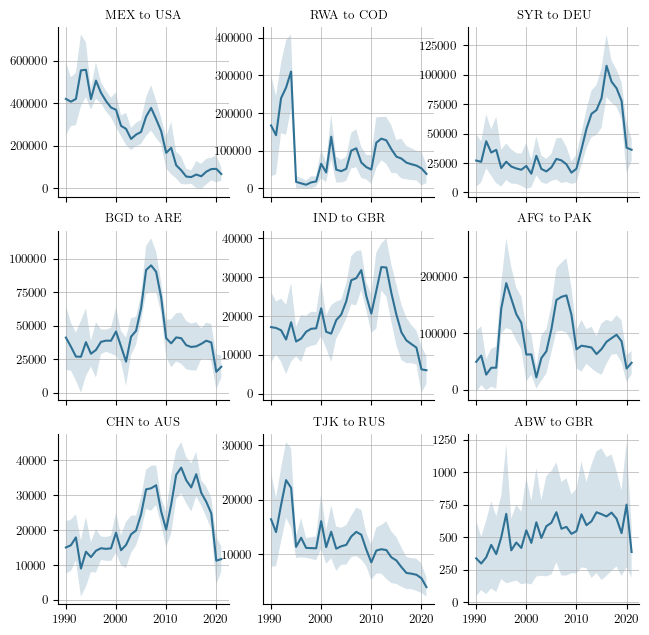

In [150]:
fig, axs = plt.subplots(ncols=3, nrows=3, sharex=True, figsize=(7.5, 7.5))
pairs = [["MEX", "USA"], ["RWA", "COD"], ["SYR", "DEU"], ["BGD", "ARE"], ["IND", "GBR"], ["AFG", "PAK"], ["CHN", "AUS"], ["TJK", "RUS"], ["ABW", "GBR"]]
for idx, pair in enumerate(pairs):
    org, dest = pair
    m = flow_table.sel({"Origin ISO": org, "Destination ISO": dest})["mean"]
    std = flow_table.sel({"Origin ISO": org, "Destination ISO": dest})["std"]
    axs.flatten()[idx].fill_between(flow_table.coords["Year"].data, m-std, m+std, alpha=0.2)
    m.plot.line(ax=axs.flatten()[idx])
    axs.flatten()[idx].set_title(f"{org} to {dest}")
    axs.flatten()[idx].set_ylabel('')
    axs.flatten()[idx].set_xlabel('')
# fig.savefig("/Users/thomasgaskin/UN_migration_data/Images/total_flow.pdf", bbox_inches='tight')

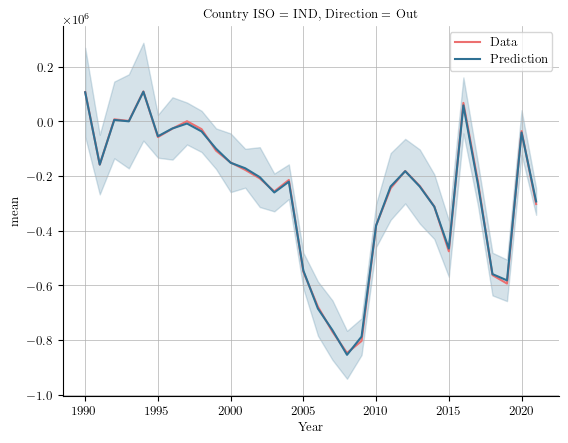

In [151]:
fig, ax = plt.subplots()
c="IND"
UN_net_migration.sel({'Year': predicted_net_migration.coords["Year"].data}).sel({"Country ISO": c}).plot(ax=ax, label="Data", color=colors["c_red"])
ax.fill_between(predicted_net_migration.coords["Year"].data,
                (predicted_net_migration["mean"] - predicted_net_migration["std"]).sel({"Country ISO": c}),
                (predicted_net_migration["mean"] + predicted_net_migration["std"]).sel({"Country ISO": c}), 
                alpha=0.2, color=colors["c_darkblue"])
predicted_net_migration["mean"].sel({"Country ISO": c}).plot(ax=ax, label="Prediction", color=colors["c_darkblue"])
ax.legend()

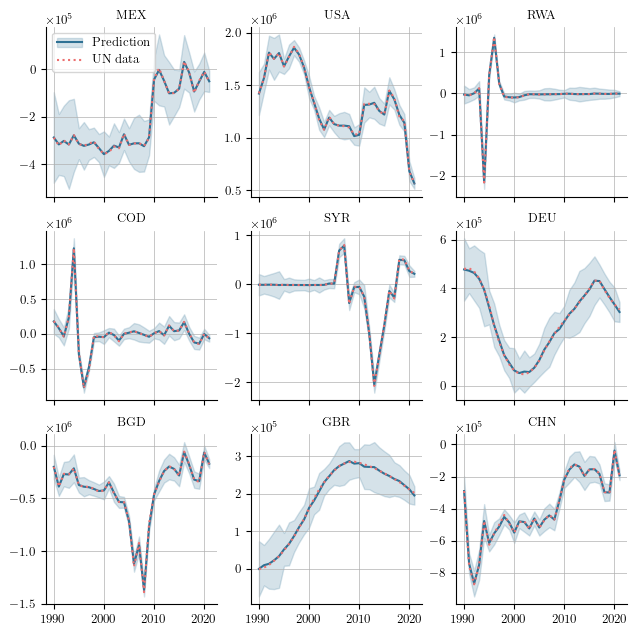

In [152]:
fig, axs = plt.subplots(ncols=3, nrows=3, sharex=True, sharey=False, figsize=(7.5, 7.5))
countries = ["MEX", "USA", "RWA", "COD", "SYR", "DEU", "BGD", "GBR", "CHN"]
for idx, c in enumerate(countries):
    f = axs.flatten()[idx].fill_between(predicted_net_migration.coords["Year"].data,
                    (predicted_net_migration["mean"] - predicted_net_migration["std"]).sel({"Country ISO": c}),
                    (predicted_net_migration["mean"] + predicted_net_migration["std"]).sel({"Country ISO": c}), 
                    alpha=0.2, color=colors["c_darkblue"])
    p = predicted_net_migration["mean"].sel({"Country ISO": c}).plot(ax=axs.flatten()[idx], label="Prediction", color=colors["c_darkblue"])
    u = UN_net_migration.sel({'Year': predicted_net_migration.coords["Year"].data}).sel({"Country ISO": c}).plot(ax=axs.flatten()[idx], label="Data", color=colors["c_red"], linestyle='dotted')
    axs.flatten()[idx].set_ylabel('')
    axs.flatten()[idx].set_xlabel('')
    axs.flatten()[idx].set_title(f"{c}")
    axs.flatten()[idx].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
axs.flatten()[0].legend(handles=[(f, p[0]), u[0]], labels=["Prediction", "UN data"])
# fig.savefig("/Users/thomasgaskin/UN_migration_data/Images/pred_net_migration.pdf")

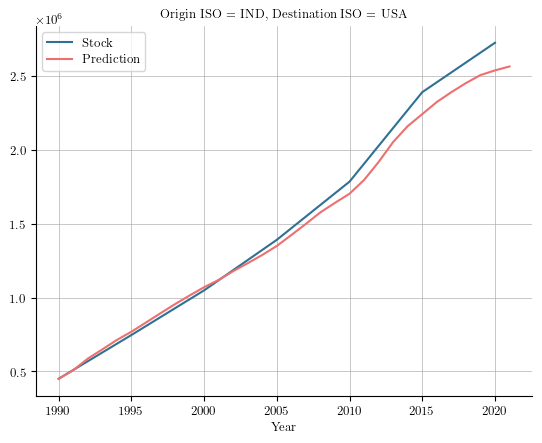

In [127]:
fig, ax = plt.subplots()
org, dest = "IND", "USA"
stock_data.sel({"Origin ISO": org, "Destination ISO": dest}).plot(ax=ax, label="Stock")

stock = [stock_data.sel({"Year": 1990, "Origin ISO": org, "Destination ISO": dest}).data]
for y in extended_flow.coords["Year"].data[1:]:
    stock.append(
        stock[-1] + extended_flow["mean"].sel({"Origin ISO": org, "Destination ISO": dest, "Direction": "Out", "Year": y}, drop=True) - extended_flow["mean"].sel({"Origin ISO": org, "Destination ISO": dest, "Direction": "In", "Year": y}, drop=True)
    )
ax.plot(extended_flow.coords["Year"].data, stock, label="Prediction")
ax.legend()

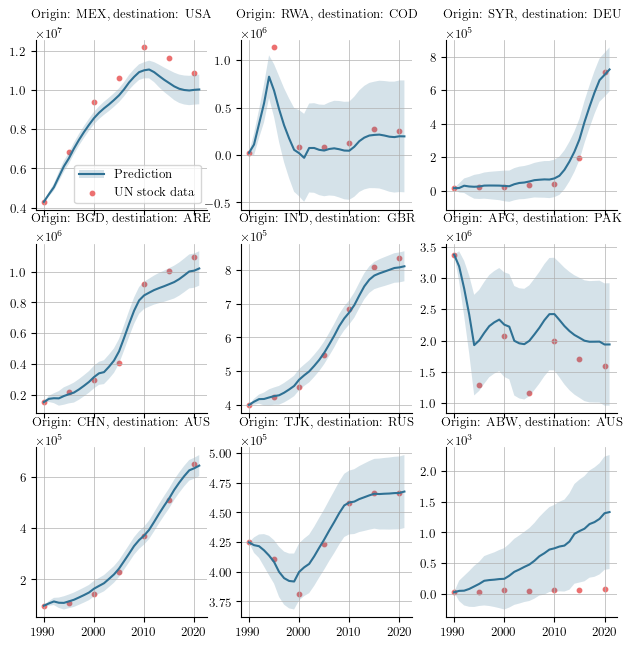

In [153]:
fig, axs = plt.subplots(ncols=3, nrows=3, sharex=True, figsize=(7.5, 7.5))
pairs = [["MEX", "USA"], ["RWA", "COD"], ["SYR", "DEU"], ["BGD", "ARE"], ["IND", "GBR"], ["AFG", "PAK"], ["CHN", "AUS"], ["TJK", "RUS"], ["ABW", "AUS"]]
for idx, pair in enumerate(pairs):
    
    org, dest = pair
    s = stock_data.sel({"Origin ISO": org, "Destination ISO": dest}).plot.scatter(ax=axs.flatten()[idx], color=colors['c_red'], x="Year", s=10)
    
    stock = [stock_data.sel({"Year": 1990, "Origin ISO": org, "Destination ISO": dest}).data]
    uncert = [0]
    for y in extended_flow.coords["Year"].data[1:]:
        stock.append(
            stock[-1] + extended_flow["mean"].sel({"Origin ISO": org, "Destination ISO": dest, "Direction": "Out", "Year": y}, drop=True) - extended_flow["mean"].sel({"Origin ISO": org, "Destination ISO": dest, "Direction": "In", "Year": y}, drop=True)
        )
        uncert.append(
            np.sqrt(uncert[-1]**2 + np.sqrt(extended_flow["std"].sel({"Origin ISO": org, "Destination ISO": dest, "Direction": "Out", "Year": y}, drop=True)**2 + extended_flow["mean"].sel({"Origin ISO": org, "Destination ISO": dest, "Direction": "In", "Year": y}, drop=True)**2)**2)
        )
    u = axs.flatten()[idx].fill_between(extended_flow.coords["Year"].data, np.array(stock) - np.array(uncert), np.array(stock) + np.array(uncert), alpha=0.2)
    p = axs.flatten()[idx].plot(extended_flow.coords["Year"].data, stock)
    axs.flatten()[idx].set_ylabel('')
    axs.flatten()[idx].set_xlabel('')
    axs.flatten()[idx].set_title(f"Origin: {org}, destination: {dest}")
    axs.flatten()[idx].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
axs.flatten()[0].legend(handles=[(u, p[0]), s], labels=['Prediction', 'UN stock data'])
# fig.savefig("/Users/thomasgaskin/UN_migration_data/Images/pred_stock.pdf")

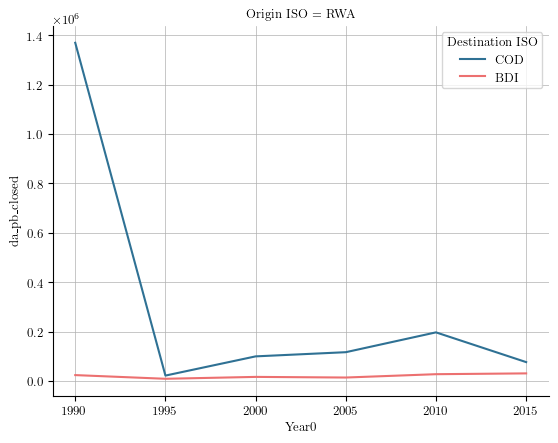

In [26]:
five_year_estimates["da_pb_closed"].sel({"Origin ISO": "RWA", "Destination ISO": ["COD", "BDI"]}).plot(hue="Destination ISO")

In [154]:
pred_five_year_estimates = []
for y in [1990, 1995, 2000, 2005, 2010, 2015]:
    pred_five_year_estimates.append(
        flow_table["mean"].sel({"Year": range(y, y+5)}).sum("Year")
    )
pred_five_year_estimates = xr.concat(pred_five_year_estimates, dim=pd.Index([1990, 1995, 2000, 2005, 2010, 2015], name="Year0"))

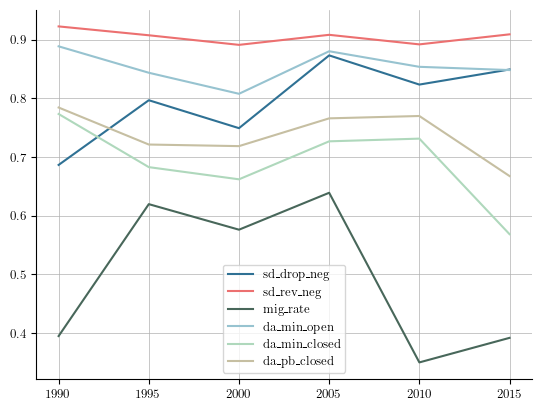

In [13]:
common_countries  = np.intersect1d(five_year_estimates.coords["Origin ISO"], pred_five_year_estimates.coords["Origin ISO"])
fig, ax = plt.subplots()
for var in list(five_year_estimates.data_vars):
    r_coeffs = []
    for year in five_year_estimates.coords["Year0"]:
        x = pred_five_year_estimates.sel({"Year0": year, "Origin ISO": common_countries, "Destination ISO": common_countries}).data.flatten()
        y = five_year_estimates[var].sel({"Year0": year, "Origin ISO": common_countries, "Destination ISO": common_countries}).data.flatten()
        msk = np.where(~np.isnan(y))
        r_coeffs.append(scipy.stats.pearsonr(x[msk], y[msk]).statistic)
    ax.plot(five_year_estimates.coords["Year0"], r_coeffs, label=var)
ax.legend()

In [155]:
bilat = pd.read_csv("/Users/thomasgaskin/UN_migration_data/global-bilat-flow-validate/val/bilat.csv")
bilat['edge'] = list(zip(bilat['orig'], bilat['dest']))
bilat.drop(["orig", "dest"], inplace=True, axis=1)
cols = list(bilat)
cols.insert(0, cols.pop(cols.index('edge')))
bilat = bilat.loc[:, cols]

In [156]:
bilat = bilat.set_index(["collection", "method"])

In [157]:
bilat.index.get_level_values('collection').unique()

Index(['celede', 'demig_c2c', 'eurostat', 'ilo_asean', 'oecd',
       'un_desa_imfsc'],
      dtype='object', name='collection')

In [158]:
for collection in ['un_desa_imfsc', 'demig_c2c', 'eurostat', 'ilo_asean']:
    
    test = bilat[(bilat.index.get_level_values('collection') == collection) & (bilat.index.get_level_values('method') == 'da_pb_closed') & (bilat.definition == "residence")].drop_duplicates()
    
    new_method = []
    
    for idx, row in test.iterrows():
        if row['edge'][0] not in pred_five_year_estimates.coords["Origin ISO"].data or row['edge'][1] not in pred_five_year_estimates.coords["Destination ISO"].data:
            continue
        row['est_flow'] = pred_five_year_estimates.sel({"Year0": row['year0'], "Origin ISO": row['edge'][0], "Destination ISO": row['edge'][1]}).data
        row['est_tot'] = pred_five_year_estimates.sel({"Year0": row['year0'], "Destination ISO": row['edge'][1]}).sum("Origin ISO").data
        row.name = (row.name[0], 'NN')
        new_method.append(row)

    NN_ests = pd.concat(new_method, axis=1).T
    NN_ests.index = NN_ests.index.set_names(['collection', 'method'])
    
    bilat = pd.concat([bilat, NN_ests], axis=0)

In [159]:
bilat = bilat.reset_index()

In [160]:
bilat['orig'] = [x[0] for x in bilat['edge']]
bilat['dest'] = [x[1] for x in bilat['edge']]

In [161]:
bilat.drop('edge', axis=1, inplace=True)

In [162]:
bilat.to_csv("/Users/thomasgaskin/UN_migration_data/global-bilat-flow-validate/val/bilat_new.csv", index=False)

In [163]:
totals = pd.read_csv("/Users/thomasgaskin/UN_migration_data/global-bilat-flow-validate/val/totals.csv")
totals = totals.set_index(['collection', 'method']).drop_duplicates()

In [164]:
for collection in ['un_desa_imfsc', 'demig_tot', 'eurostat', 'ilo_asean']:
    
    test = totals[(totals.index.get_level_values('collection') == collection) & (totals.index.get_level_values('method') == 'da_pb_closed') & (totals.definition == "residence")].drop_duplicates()
    
    new_method = []
    
    for idx, row in test.iterrows():
        if row['iso3c'] not in predicted_net_migration.coords["Country ISO"].data:
            continue
        row['emi'] = (flow_table.sel({"Origin ISO": row["iso3c"], "Year": range(row['year0'], row['year0']+5)})["mean"].sum(["Destination ISO", "Year"])).data.item()
        row['imm'] = (flow_table.sel({"Destination ISO": row["iso3c"], "Year": range(row['year0'], row['year0']+5)})["mean"].sum(["Origin ISO", "Year"])).data.item()
        row['net'] = row['imm'] - row['emi']
        row.name = (row.name[0], 'NN')
        new_method.append(row)

    NN_ests = pd.concat(new_method, axis=1).T
    NN_ests.index = NN_ests.index.set_names(['collection', 'method'])
    
    totals = pd.concat([totals, NN_ests], axis=0)

In [165]:
totals = totals.reset_index()

In [166]:
totals.to_csv("/Users/thomasgaskin/UN_migration_data/global-bilat-flow-validate/val/totals_new.csv", index=False)

<Axes: xlabel='year0'>

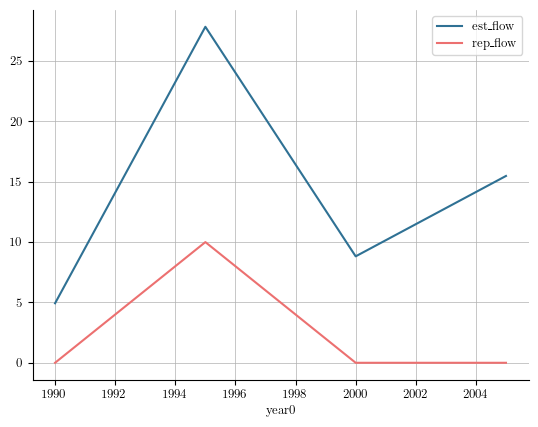

In [188]:
fig, ax = plt.subplots()
bilat[(bilat.collection == 'un_desa_imfsc') & (bilat.method == 'da_pb_closed') & (bilat.orig == 'ABW') & (bilat.dest == 'AUS')][['year0', 'est_flow', 'rep_flow']].plot(x='year0', ax=ax)
# pred_five_year_estimates.sel({"Origin ISO": "ABW", 'Destination ISO': "AUS"}).plot(x='Year0', ax=ax)

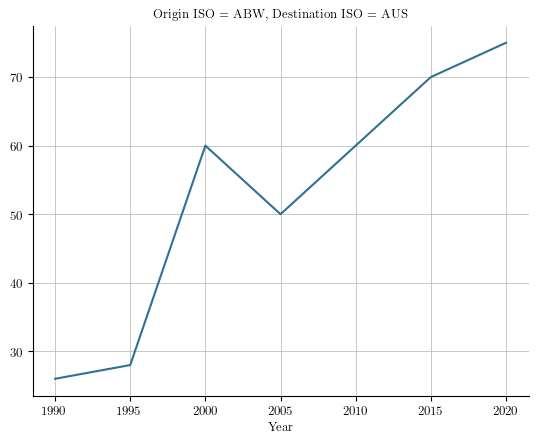

In [187]:
stock_data.sel({"Origin ISO": "ABW", "Destination ISO": "AUS"}).plot()

In [182]:
bilat[(bilat.collection == 'un_desa_imfsc') & (bilat.method == 'da_pb_closed') & (bilat.orig == 'ABW') & (bilat.dest == 'AUS')][['year0', 'est_flow', 'rep_flow']]

,year0,est_flow,rep_flow
1970849,1990,4.93,0.0
1970855,1990,4.93,0.0
1970861,1990,4.93,0.0
1970867,1990,4.93,0.0
1970873,1990,4.93,0.0
1970879,1995,27.84,10.0
1970885,1995,27.84,10.0
1970891,1995,27.84,10.0
1970897,1995,27.84,10.0
1970903,1995,27.84,10.0
